In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
from pathlib import Path

flight = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado/carbonZ_2018-07-18-16-37-39_1_no_failure")

for f in flight.iterdir():
    print(f.name)

carbonZ_2018-07-18-16-37-39_1_no_failure-mavros-global_position-raw-fix.csv
carbonZ_2018-07-18-16-37-39_1_no_failure-mavros-global_position-compass_hdg.csv
carbonZ_2018-07-18-16-37-39_1_no_failure-mavros-global_position-global.csv
carbonZ_2018-07-18-16-37-39_1_no_failure-mavros-global_position-local.csv
carbonZ_2018-07-18-16-37-39_1_no_failure-mavros-global_position-raw-gps_vel.csv
carbonZ_2018-07-18-16-37-39_1_no_failure-mavros-global_position-rel_alt.csv
carbonZ_2018-07-18-16-37-39_1_no_failure-mavros-imu-atm_pressure.csv
carbonZ_2018-07-18-16-37-39_1_no_failure-mavros-imu-data.csv
carbonZ_2018-07-18-16-37-39_1_no_failure-mavros-imu-data_raw.csv
carbonZ_2018-07-18-16-37-39_1_no_failure-mavros-imu-mag.csv
carbonZ_2018-07-18-16-37-39_1_no_failure-mavros-imu-temperature.csv
carbonZ_2018-07-18-16-37-39_1_no_failure-mavros-local_position-odom.csv
carbonZ_2018-07-18-16-37-39_1_no_failure-mavros-local_position-pose.csv
carbonZ_2018-07-18-16-37-39_1_no_failure-mavros-local_position-velocity.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

DATA_ROOT = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")

flights = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir() and not p.name.startswith("_")])

no_failure_flights = [f for f in flights if "no_failure" in f.name]
engine_failure_flights = [f for f in flights if "engine_failure" in f.name]

selected_flights = []
selected_flights.extend(no_failure_flights[:2])
selected_flights.append(engine_failure_flights[0])

print("Voos escolhidos:")
for f in selected_flights:
    print(f.name)

def make_time_s(df, time_col="pcttime"):
    t = pd.to_numeric(df[time_col], errors="coerce")
    med = np.nanmedian(t.to_numpy()) if np.isfinite(t.to_numpy()).any() else np.nan

    if np.isfinite(med) and med > 1e12:
        t = t / 1e9
    elif np.isfinite(med) and med > 1e9:
        t = t / 1e3
    else:
        t = t.astype("float64")

    t0 = np.nanmin(t.to_numpy()) if np.isfinite(t.to_numpy()).any() else 0.0
    return (t - t0).astype("float64")

def build_consolidated(flight_dir):
    battery_files = list(flight_dir.glob("*mavros-battery*.csv"))
    odom_files = list(flight_dir.glob("*mavros-local_position-odom*.csv"))

    if len(battery_files) == 0:
        return {"flight": flight_dir.name, "status": "battery ausente"}
    if len(odom_files) == 0:
        return {"flight": flight_dir.name, "status": "odom ausente"}

    battery = pd.read_csv(battery_files[0], low_memory=False)
    odom = pd.read_csv(odom_files[0], low_memory=False)

    battery["time_s"] = make_time_s(battery, "pcttime")
    odom["time_s"] = make_time_s(odom, "pcttime")

    battery = battery.drop_duplicates(subset=["time_s"]).sort_values("time_s")
    odom = odom.drop_duplicates(subset=["time_s"]).sort_values("time_s")

    battery = battery[[
        "time_s",
        "field_voltage",
        "field_current",
        "field_percentage",
        "field_power_supply_status",
        "field_power_supply_health",
        "field_present",
    ]]

    odom = odom[[
        "time_s",
        "field_pose_pose_position_x",
        "field_pose_pose_position_y",
        "field_pose_pose_position_z",
        "field_twist_twist_linear_x",
        "field_twist_twist_linear_y",
        "field_twist_twist_linear_z",
        "field_twist_twist_angular_x",
        "field_twist_twist_angular_y",
        "field_twist_twist_angular_z",
    ]]

    battery = battery.rename(columns={
        "field_voltage": "voltage_v",
        "field_current": "current_a",
        "field_percentage": "battery_pct",
        "field_power_supply_status": "battery_status",
        "field_power_supply_health": "battery_health",
        "field_present": "battery_present",
    })

    odom = odom.rename(columns={
        "field_pose_pose_position_x": "x_m",
        "field_pose_pose_position_y": "y_m",
        "field_pose_pose_position_z": "z_m",
        "field_twist_twist_linear_x": "vx_mps",
        "field_twist_twist_linear_y": "vy_mps",
        "field_twist_twist_linear_z": "vz_mps",
        "field_twist_twist_angular_x": "wx_rps",
        "field_twist_twist_angular_y": "wy_rps",
        "field_twist_twist_angular_z": "wz_rps",
    })

    battery = battery.sort_values("time_s").reset_index(drop=True)
    odom = odom.sort_values("time_s").reset_index(drop=True)

    consolidated = pd.merge_asof(
        odom,
        battery,
        on="time_s",
        direction="nearest",
        tolerance=0.25
    )

    consolidated["speed_mps"] = np.sqrt(
        consolidated["vx_mps"]**2 +
        consolidated["vy_mps"]**2 +
        consolidated["vz_mps"]**2
    )

    consolidated["power_w"] = consolidated["voltage_v"] * consolidated["current_a"]

    out_path = flight_dir / "flight_consolidated.csv"
    consolidated.to_csv(out_path, index=False)

    return {
        "flight": flight_dir.name,
        "status": "ok",
        "rows": consolidated.shape[0],
        "cols": consolidated.shape[1],
        "saved_to": str(out_path)
    }

results = []

for flight in selected_flights:
    result = build_consolidated(flight)
    results.append(result)

results_df = pd.DataFrame(results)

print("\nResultado:")
print(results_df)

Voos escolhidos:
carbonZ_2018-07-18-16-37-39_1_no_failure
carbonZ_2018-07-30-16-39-00_3_no_failure
carbonZ_2018-07-18-15-53-31_1_engine_failure

Resultado:
                                         flight status  rows  cols  \
0      carbonZ_2018-07-18-16-37-39_1_no_failure     ok   126    18   
1      carbonZ_2018-07-30-16-39-00_3_no_failure     ok   324    18   
2  carbonZ_2018-07-18-15-53-31_1_engine_failure     ok   544    18   

                                            saved_to  
0  /content/gdrive/MyDrive/datasets/ALFA/processe...  
1  /content/gdrive/MyDrive/datasets/ALFA/processe...  
2  /content/gdrive/MyDrive/datasets/ALFA/processe...  


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

selected_flights = [
    Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado/carbonZ_2018-07-18-16-37-39_1_no_failure"),
    Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado/carbonZ_2018-07-30-16-39-00_3_no_failure"),
    Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado/carbonZ_2018-07-18-15-53-31_1_engine_failure")
]

def run_detector(flight_dir, threshold=3.0):
    csv_path = flight_dir / "flight_consolidated.csv"
    df = pd.read_csv(csv_path)

    for col in ["time_s", "vx_mps", "vy_mps"]:
        if col not in df.columns:
            return {
                "flight": flight_dir.name,
                "status": f"coluna ausente: {col}",
                "n_points": None,
                "n_anomalies": None,
                "anomaly_rate": None,
                "max_abs_z": None
            }

    t = df["time_s"].to_numpy(dtype=float)
    vx = df["vx_mps"].to_numpy(dtype=float)
    vy = df["vy_mps"].to_numpy(dtype=float)

    eps = 1e-9

    dt = np.gradient(t)
    ax = np.gradient(vx) / (dt + eps)
    ay = np.gradient(vy) / (dt + eps)

    speed2 = vx**2 + vy**2
    yaw_rate = (vx * ay - vy * ax) / (speed2 + eps)

    tmp = pd.DataFrame({
        "time_s": t,
        "yaw_rate_proxy_rps": yaw_rate
    })

    tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna()

    x = tmp["yaw_rate_proxy_rps"].to_numpy(dtype=float)

    if len(x) == 0:
        return {
            "flight": flight_dir.name,
            "status": "sem dados válidos",
            "n_points": 0,
            "n_anomalies": 0,
            "anomaly_rate": 0.0,
            "max_abs_z": None
        }

    med = np.median(x)
    mad = np.median(np.abs(x - med)) + 1e-12

    tmp["z_robust"] = 0.6745 * (tmp["yaw_rate_proxy_rps"] - med) / mad
    tmp["anomaly_flag"] = tmp["z_robust"].abs() > threshold

    return {
        "flight": flight_dir.name,
        "status": "ok",
        "n_points": len(tmp),
        "n_anomalies": int(tmp["anomaly_flag"].sum()),
        "anomaly_rate": float(tmp["anomaly_flag"].mean()),
        "max_abs_z": float(tmp["z_robust"].abs().max())
    }

results = []

for flight in selected_flights:
    results.append(run_detector(flight, threshold=3.0))

results_df = pd.DataFrame(results)

print(results_df)

                                         flight status  n_points  n_anomalies  \
0      carbonZ_2018-07-18-16-37-39_1_no_failure     ok       126           10   
1      carbonZ_2018-07-30-16-39-00_3_no_failure     ok       324           12   
2  carbonZ_2018-07-18-15-53-31_1_engine_failure     ok       544           12   

   anomaly_rate  max_abs_z  
0      0.079365   4.327816  
1      0.037037   5.034856  
2      0.022059   5.770444  


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

DATA_ROOT = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")

flights = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir() and not p.name.startswith("_")])

print("Total de voos encontrados:", len(flights))

def make_time_s(df, time_col="pcttime"):
    t = pd.to_numeric(df[time_col], errors="coerce")
    med = np.nanmedian(t.to_numpy()) if np.isfinite(t.to_numpy()).any() else np.nan

    if np.isfinite(med) and med > 1e12:
        t = t / 1e9
    elif np.isfinite(med) and med > 1e9:
        t = t / 1e3
    else:
        t = t.astype("float64")

    t0 = np.nanmin(t.to_numpy()) if np.isfinite(t.to_numpy()).any() else 0.0
    return (t - t0).astype("float64")

def build_consolidated(flight_dir):
    out_path = flight_dir / "flight_consolidated.csv"

    if out_path.exists():
        return out_path, "ja_existia"

    battery_files = list(flight_dir.glob("*mavros-battery*.csv"))
    odom_files = list(flight_dir.glob("*mavros-local_position-odom*.csv"))

    if len(battery_files) == 0:
        return None, "battery_ausente"

    if len(odom_files) == 0:
        return None, "odom_ausente"

    try:
        battery = pd.read_csv(battery_files[0], low_memory=False)
        odom = pd.read_csv(odom_files[0], low_memory=False)

        battery["time_s"] = make_time_s(battery, "pcttime")
        odom["time_s"] = make_time_s(odom, "pcttime")

        battery = battery.drop_duplicates(subset=["time_s"]).sort_values("time_s")
        odom = odom.drop_duplicates(subset=["time_s"]).sort_values("time_s")

        battery = battery[[
            "time_s",
            "field_voltage",
            "field_current",
            "field_percentage",
            "field_power_supply_status",
            "field_power_supply_health",
            "field_present",
        ]]

        odom = odom[[
            "time_s",
            "field_pose_pose_position_x",
            "field_pose_pose_position_y",
            "field_pose_pose_position_z",
            "field_twist_twist_linear_x",
            "field_twist_twist_linear_y",
            "field_twist_twist_linear_z",
            "field_twist_twist_angular_x",
            "field_twist_twist_angular_y",
            "field_twist_twist_angular_z",
        ]]

        battery = battery.rename(columns={
            "field_voltage": "voltage_v",
            "field_current": "current_a",
            "field_percentage": "battery_pct",
            "field_power_supply_status": "battery_status",
            "field_power_supply_health": "battery_health",
            "field_present": "battery_present",
        })

        odom = odom.rename(columns={
            "field_pose_pose_position_x": "x_m",
            "field_pose_pose_position_y": "y_m",
            "field_pose_pose_position_z": "z_m",
            "field_twist_twist_linear_x": "vx_mps",
            "field_twist_twist_linear_y": "vy_mps",
            "field_twist_twist_linear_z": "vz_mps",
            "field_twist_twist_angular_x": "wx_rps",
            "field_twist_twist_angular_y": "wy_rps",
            "field_twist_twist_angular_z": "wz_rps",
        })

        battery = battery.sort_values("time_s").reset_index(drop=True)
        odom = odom.sort_values("time_s").reset_index(drop=True)

        consolidated = pd.merge_asof(
            odom,
            battery,
            on="time_s",
            direction="nearest",
            tolerance=0.25
        )

        consolidated["speed_mps"] = np.sqrt(
            consolidated["vx_mps"]**2 +
            consolidated["vy_mps"]**2 +
            consolidated["vz_mps"]**2
        )

        consolidated["power_w"] = consolidated["voltage_v"] * consolidated["current_a"]

        consolidated.to_csv(out_path, index=False)
        return out_path, "criado"

    except Exception as e:
        return None, f"erro_consolidacao: {e}"

def run_detector(csv_path, threshold=3.0):
    try:
        df = pd.read_csv(csv_path)

        for col in ["time_s", "vx_mps", "vy_mps"]:
            if col not in df.columns:
                return {
                    "status_detector": f"coluna_ausente_{col}",
                    "n_points": None,
                    "n_anomalies": None,
                    "anomaly_rate": None,
                    "max_abs_z": None
                }

        t = df["time_s"].to_numpy(dtype=float)
        vx = df["vx_mps"].to_numpy(dtype=float)
        vy = df["vy_mps"].to_numpy(dtype=float)

        eps = 1e-9

        dt = np.gradient(t)
        ax = np.gradient(vx) / (dt + eps)
        ay = np.gradient(vy) / (dt + eps)

        speed2 = vx**2 + vy**2
        yaw_rate = (vx * ay - vy * ax) / (speed2 + eps)

        tmp = pd.DataFrame({
            "time_s": t,
            "yaw_rate_proxy_rps": yaw_rate
        })

        tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna()

        x = tmp["yaw_rate_proxy_rps"].to_numpy(dtype=float)

        if len(x) == 0:
            return {
                "status_detector": "sem_dados_validos",
                "n_points": 0,
                "n_anomalies": 0,
                "anomaly_rate": 0.0,
                "max_abs_z": None
            }

        med = np.median(x)
        mad = np.median(np.abs(x - med)) + 1e-12

        tmp["z_robust"] = 0.6745 * (tmp["yaw_rate_proxy_rps"] - med) / mad
        tmp["anomaly_flag"] = tmp["z_robust"].abs() > threshold

        return {
            "status_detector": "ok",
            "n_points": len(tmp),
            "n_anomalies": int(tmp["anomaly_flag"].sum()),
            "anomaly_rate": float(tmp["anomaly_flag"].mean()),
            "max_abs_z": float(tmp["z_robust"].abs().max())
        }

    except Exception as e:
        return {
            "status_detector": f"erro_detector: {e}",
            "n_points": None,
            "n_anomalies": None,
            "anomaly_rate": None,
            "max_abs_z": None
        }

results = []

for i, flight in enumerate(flights, start=1):
    csv_path, status_build = build_consolidated(flight)

    if csv_path is None:
        results.append({
            "flight": flight.name,
            "status_consolidated": status_build,
            "status_detector": None,
            "n_points": None,
            "n_anomalies": None,
            "anomaly_rate": None,
            "max_abs_z": None
        })
    else:
        det = run_detector(csv_path, threshold=3.0)

        results.append({
            "flight": flight.name,
            "status_consolidated": status_build,
            "status_detector": det["status_detector"],
            "n_points": det["n_points"],
            "n_anomalies": det["n_anomalies"],
            "anomaly_rate": det["anomaly_rate"],
            "max_abs_z": det["max_abs_z"]
        })

    if i % 10 == 0 or i == len(flights):
        print(f"{i}/{len(flights)} voos processados")

results_df = pd.DataFrame(results)

out_file = DATA_ROOT / "detector_todos_os_voos.csv"
results_df.to_csv(out_file, index=False)

print("\nArquivo salvo em:")
print(out_file)

print("\nResumo geral:")
print(results_df.head())

Total de voos encontrados: 47
10/47 voos processados
20/47 voos processados
30/47 voos processados
40/47 voos processados
47/47 voos processados

Arquivo salvo em:
/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado/detector_todos_os_voos.csv

Resumo geral:
                                              flight status_consolidated  \
0        carbonZ_2018-07-18-12-10-11_no_ground_truth          ja_existia   
1       carbonZ_2018-07-18-15-53-31_1_engine_failure          ja_existia   
2       carbonZ_2018-07-18-15-53-31_2_engine_failure              criado   
3  carbonZ_2018-07-18-16-22-01_engine_failure_wit...              criado   
4           carbonZ_2018-07-18-16-37-39_1_no_failure          ja_existia   

  status_detector  n_points  n_anomalies  anomaly_rate  max_abs_z  
0              ok       838            6      0.007160   4.334712  
1              ok       544           12      0.022059   5.770444  
2              ok       366           20      0.054645   5.

Contagem de voos por tipo:
flight_type
engine_failure     23
other              13
no_failure         10
no_ground_truth     1
Name: count, dtype: int64


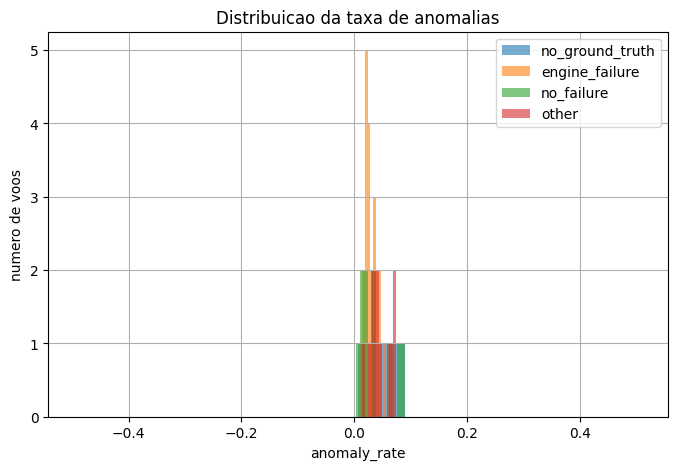

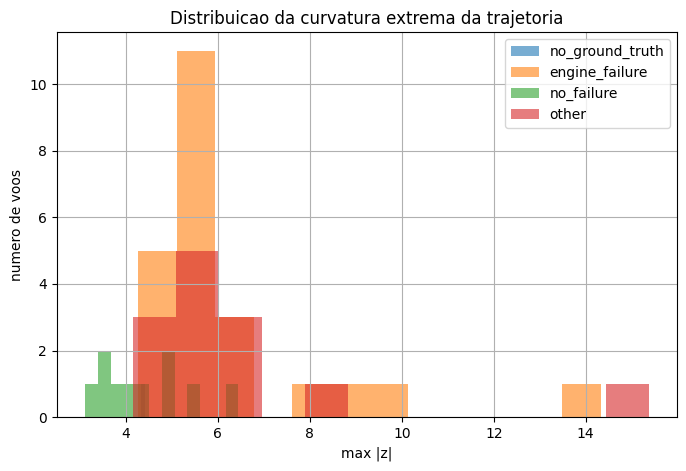

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data_root = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")

file_path = data_root / "detector_todos_os_voos.csv"

df = pd.read_csv(file_path)

# manter apenas voos onde o detector rodou
df = df[df["status_detector"] == "ok"].copy()

# classificar o tipo de voo pelo nome
types = []
for name in df["flight"]:
    if "engine_failure" in name:
        types.append("engine_failure")
    elif "no_failure" in name:
        types.append("no_failure")
    elif "no_ground_truth" in name:
        types.append("no_ground_truth")
    else:
        types.append("other")

df["flight_type"] = types

print("Contagem de voos por tipo:")
print(df["flight_type"].value_counts())

# gráfico da taxa de anomalias
plt.figure(figsize=(8,5))

for t in df["flight_type"].unique():
    subset = df[df["flight_type"] == t]
    plt.hist(subset["anomaly_rate"], bins=12, alpha=0.6, label=t)

plt.xlabel("anomaly_rate")
plt.ylabel("numero de voos")
plt.title("Distribuicao da taxa de anomalias")
plt.legend()
plt.grid(True)
plt.show()


# gráfico do valor máximo de z
plt.figure(figsize=(8,5))

for t in df["flight_type"].unique():
    subset = df[df["flight_type"] == t]
    plt.hist(subset["max_abs_z"], bins=12, alpha=0.6, label=t)

plt.xlabel("max |z|")
plt.ylabel("numero de voos")
plt.title("Distribuicao da curvatura extrema da trajetoria")
plt.legend()
plt.grid(True)
plt.show()